In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.columns.tolist()

['UDI',
 'Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [4]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [5]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [6]:
df["Machine failure"].value_counts(normalize=True)*100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

The target is highly imbalanced. Only around 3.4% of rows are machine failure.
i.e. accuracy is no good matrix.

In [7]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [8]:
df.groupby("Type")["Machine failure"].mean().sort_values(ascending=False)*100

Type
L    3.916667
M    2.769436
H    2.093719
Name: Machine failure, dtype: float64

In [9]:
leakage_col = ["TWF", "HDF", "PWF", "OSF", "RNF"]
id_col = ["UDI", "Product ID"]
feature_col = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
target_col = "Machine failure"

In [10]:
df[feature_col + [target_col]].head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


I will not use the failure mode cols as input features because they describe the failure outcome. Including them would cause target leakage. And also ID cols will not be used for obvious reasons.

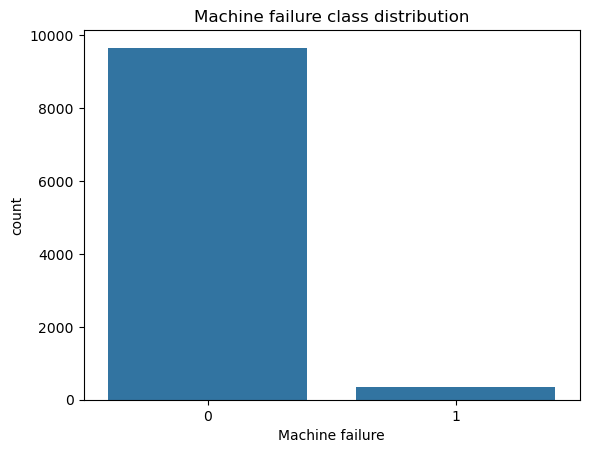

In [ ]:
# Target count plot
sns.countplot(data=df , x="Machine failure")
plt.title("Machine failure class distribution")
plt.show()

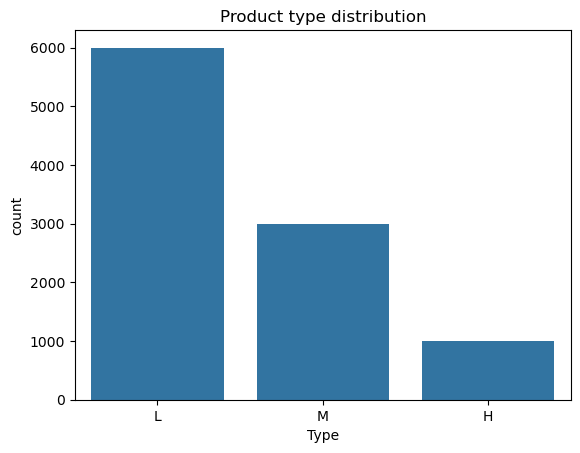

In [16]:
# Product type distribution
sns.countplot(data=df, x="Type", order=df["Type"].value_counts().index)
plt.title("Product type distribution")
plt.show()

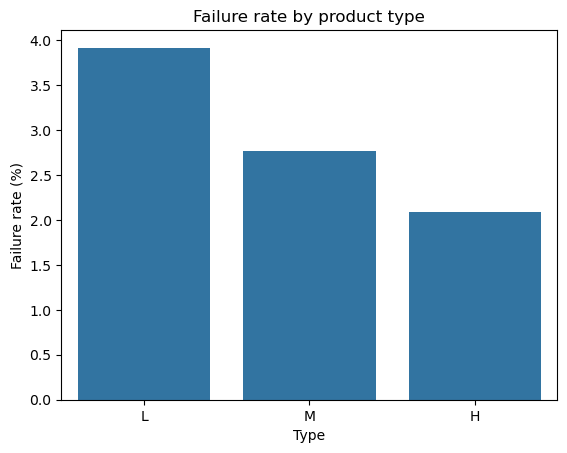

In [21]:
# Failure rate by product type
failure_rate_by_type = df.groupby("Type")["Machine failure"].mean().sort_values(ascending=False)

sns.barplot(x=failure_rate_by_type.index, y=failure_rate_by_type.values*100)
plt.title("Failure rate by product type")
plt.ylabel("Failure rate (%)")
plt.show()

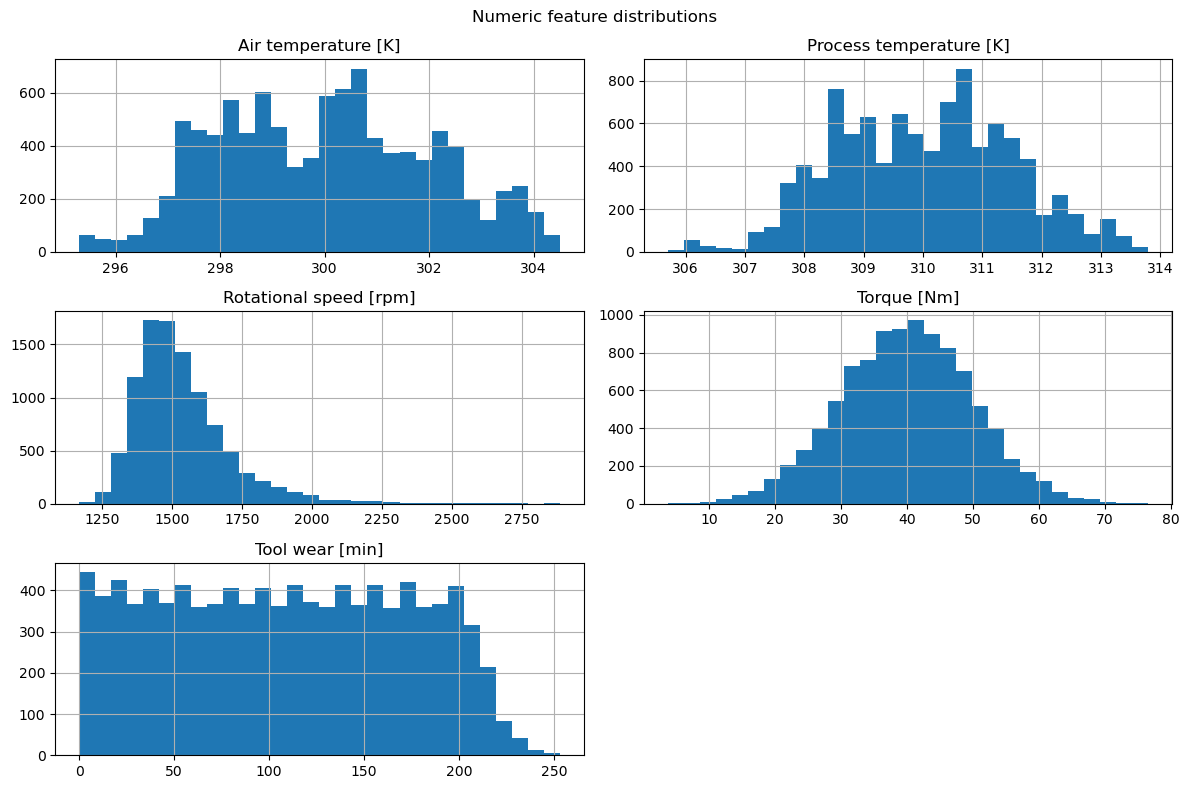

In [22]:
# Numeric Distributions
df[feature_col[1:]].hist(figsize=(12,8),bins=30)
plt.suptitle("Numeric feature distributions")
plt.tight_layout()
plt.show()

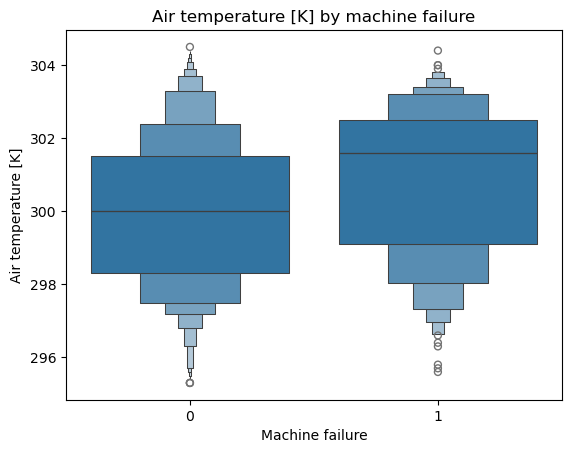

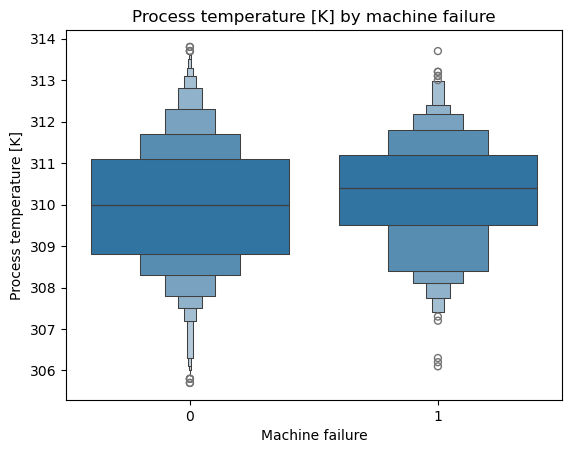

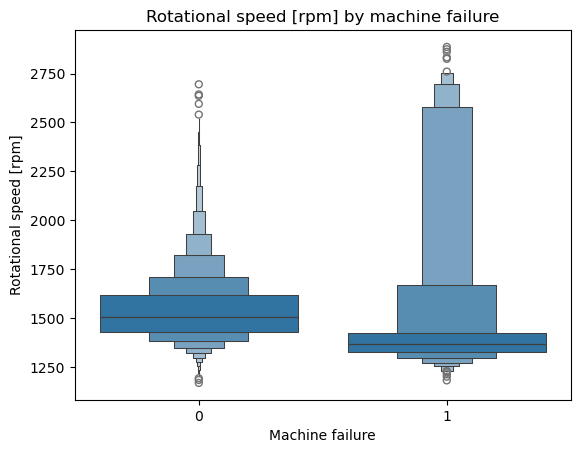

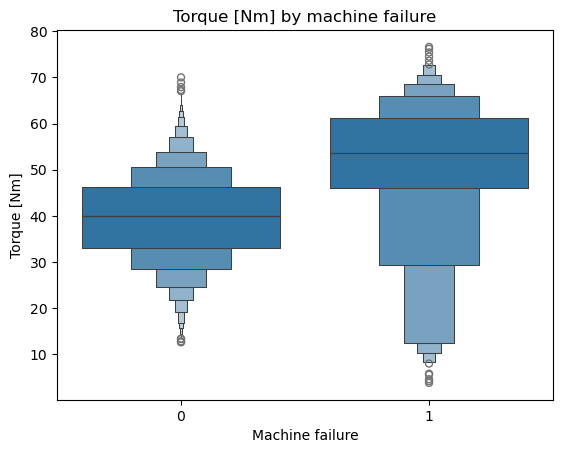

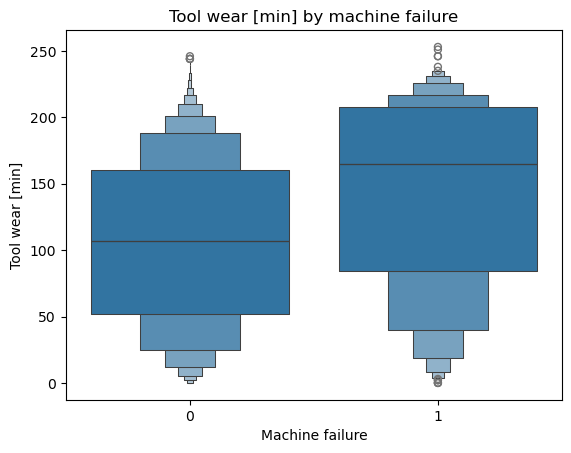

In [25]:
# Boxplots by target
numeric_features = feature_col[1:]
for col in numeric_features:
    sns.boxenplot(data=df, x="Machine failure", y=col)
    plt.title(f"{col} by machine failure")
    plt.show()

## EDA summary

The dataset has a strong class imbalance: only a small percentage of machines fail. This means accuracy alone is not enough for model evaluation.

The failure-mode columns (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) should not be used as input features because they describe the failure outcome and would cause target leakage.

The sensor features have different value ranges, and the boxplots show some differences between failed and non-failed machines. The groups still overlap, so no single feature perfectly separates failures. A model needs to combine multiple features.